# Chapter 1 — Foundations: Prices and Returns

Read the chapter [`README.md`](./README.md) first for the full discussion. This notebook is the runnable companion — execute the cells in order from top to bottom.

If a cell errors with `ModuleNotFoundError`, run `pip install -r ../requirements.txt` from the repo root, then restart the kernel.

## 1. Setup check

Confirm the libraries we need are importable.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"yfinance   {yf.__version__}")

numpy      2.4.4
pandas     3.0.2
yfinance   1.3.0


## 2. Download price data

We'll pull 5 years of daily data for **SPY**, the SPDR S&P 500 **ETF** — a clean stand-in for "the U.S. stock market" (README §3 for what an *ETF* and an *index* are).

In the next cell:
- **Ticker** — the short symbol identifying the security on an exchange (here, `"SPY"`).
- **`period="5y"`** — `yfinance` shorthand for "the last 5 years."

`yfinance` returns a pandas `DataFrame` with one row per **trading day** (~252 days per year — weekends and U.S. market holidays don't count) and columns **Open / High / Low / Close / Volume** (*OHLCV*). The `Close` column is **adjusted** — corrected for splits and dividends — so it can be used directly for return math.

In [76]:
ticker = "SPY"
data = yf.download(ticker, period="5y", progress=False)
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2026-04-20,708.719971,709.909973,706.140015,708.780029,43546800
2026-04-21,704.080017,711.280029,702.640015,710.280029,58941400
2026-04-22,711.210022,711.450012,708.219971,709.150024,42518500
2026-04-23,708.450012,712.359985,702.280029,709.500000,56174000
2026-04-24,713.940002,714.469971,709.010010,710.750000,45123600


Modern `yfinance` returns `Close` already adjusted for splits and dividends — that's the column we want for return math.

We use `.squeeze()` to flatten a single-column DataFrame down to a 1-D Series, which makes downstream code simpler. Then `.describe()` gives a quick summary — count, mean, standard deviation, min, max, and the 25th/50th/75th percentiles.

In [77]:
prices = data["Close"].squeeze()
assert isinstance(prices, pd.Series)
prices.describe()

count    1256.000000
mean      488.163791
std       103.738171
min       340.252869
25%       400.479874
50%       440.711716
75%       574.897827
max       713.940002
Name: SPY, dtype: float64

## 3. Compute returns

A **return** is the percentage change in price between two times — unitless, comparable across assets, and what most quant analysis is actually about. Two flavors:

- **Simple return:** *r<sub>t</sub>* = *P<sub>t</sub>* / *P<sub>t−1</sub>* − 1 — what a brokerage statement reports.
- **Log return:** *r<sub>t</sub>* = ln(*P<sub>t</sub>* / *P<sub>t−1</sub>*) — what most quant math uses, because log returns *add* across periods.

where:
- *r<sub>t</sub>* — the return for period *t*.
- *P<sub>t</sub>* — the price at the close of period *t*.
- *P<sub>t−1</sub>* — the price one period earlier (the previous day's close, for daily data).
- *t* — a time index labeling each period (a specific trading day, here).
- *ln* — natural logarithm (log base *e*).

For small daily moves the two are nearly identical (README §2 explains why and when the difference matters).

In the next cell:
- `.pct_change()` is pandas shorthand for the simple return at each step.
- `.shift(1)` slides the series forward one step, so `prices / prices.shift(1)` is the price ratio *P<sub>t</sub>* / *P<sub>t−1</sub>*.
- `.dropna()` removes the first row, which has no prior price to compare against (so its return is `NaN`).

In [78]:
simple_returns = prices.pct_change().dropna()
log_returns    = np.log(prices / prices.shift(1)).dropna()

pd.DataFrame({"simple": simple_returns, "log": log_returns}).head()

,simple,log
Date,,
2021-04-27,-0.000215,-0.000215
2021-04-28,-0.000288,-0.000288
2021-04-29,0.006373,0.006352
2021-04-30,-0.006570,-0.006592
2021-05-03,0.002157,0.002154


Notice how close `simple` and `log` are — for daily data they almost coincide.

## 4. Visualize

Two of the most common plots in quant analysis:

- A **price line chart** — price on the y-axis, time on the x-axis. Useful for spotting trends, **drawdowns** (peak-to-trough declines), and major events.
- A **return histogram** — buckets daily returns into bins and shows how many days fell in each bin. The shape that emerges is the **distribution** of returns. Most days cluster near zero; the rare large moves at the edges are the **tails**.

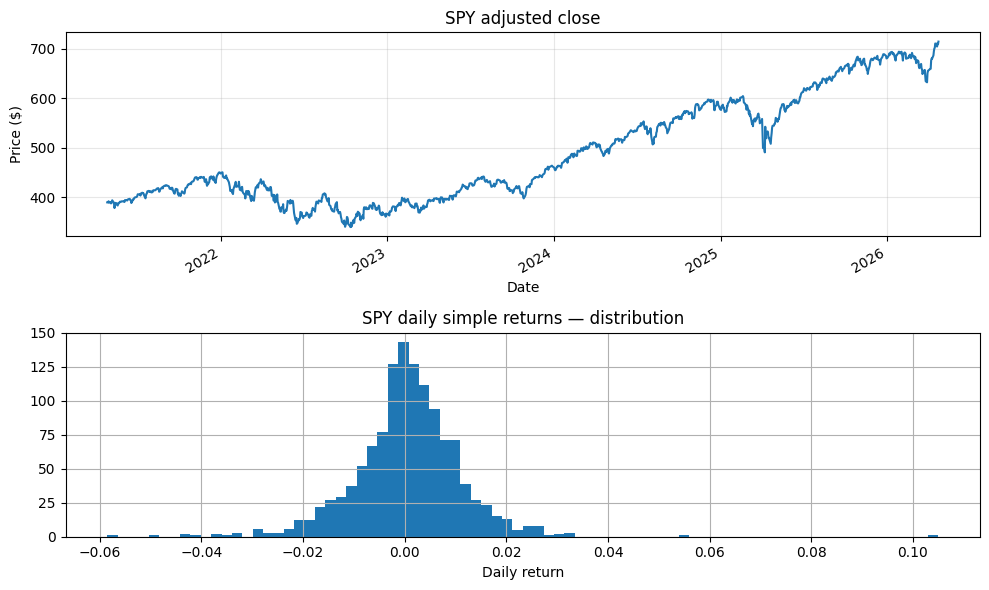

In [79]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

prices.plot(ax=axes[0], title=f"{ticker} adjusted close")
axes[0].set_ylabel("Price ($)")
axes[0].grid(alpha=0.3)

simple_returns.hist(ax=axes[1], bins=80)
axes[1].set_title(f"{ticker} daily simple returns — distribution")
axes[1].set_xlabel("Daily return")

plt.tight_layout()
plt.show()

A few things to look for in the output:

- The price chart trends upward but with the COVID **drawdown** in March 2020 and the 2022 **correction** clearly visible.
- The histogram is roughly **bell-shaped** (close to a *normal distribution*) but with a few outliers in the ±3% to ±5% range — those are the **fat tails** that real-market returns are notorious for, and that Chapter 2 will dwell on.

## 5. Summary statistics

Two numbers do most of the work in describing the histogram above:

- **Mean (μ)** — the arithmetic average of the daily returns. Tells us where the histogram is *centered*.
- **Standard deviation (σ)** — the square root of the **variance** (the average squared deviation from the mean). Tells us how *wide* the histogram is.

The standard deviation of returns is what we call **volatility** — our quantitative measure of risk (README §4).

In [80]:
daily_mean = simple_returns.mean()
log_daily_std  = simple_returns.std()

print(f"Daily mean return:        {daily_mean:.5f}  ({daily_mean*100:.3f}%)")
print(f"Daily standard deviation: {log_daily_std:.5f}  ({log_daily_std*100:.3f}%)")

Daily mean return:        0.00054  (0.054%)
Daily standard deviation: 0.01077  (1.077%)


### Annualizing

Convention: ~252 trading days per year.
- Annualized return ≈ daily mean × 252
- Annualized volatility ≈ daily std × √252

(See the chapter README for *why* it's √252 and not 252.)

In [81]:
trading_days = 252
log_ann_return = daily_mean * trading_days
log_ann_vol    = log_daily_std * np.sqrt(trading_days)

print(f"Annualized return:     {log_ann_return*100:.2f}%")
print(f"Annualized volatility: {log_ann_vol*100:.2f}%")

Annualized return:     13.60%
Annualized volatility: 17.09%


For a broad U.S. equity **index** over a multi-year window, **annualized volatility around 15–25%** is typical. If you got a number in that range, you computed it correctly. Single stocks generally come in higher (often 25–50%); the diversification of an index basket smooths things out.

## Exercises

Try these in fresh cells below. Copy any code cell above as a starting point.

1. **Different ticker.** Re-run with `AAPL`, `MSFT`, or `BRK-B`. Which has the highest annualized volatility?
2. **Different window.** Restrict to the most recent 1 year (`period="1y"`) and recompute annualized vol. Does it match the 5-year number?
3. **Simple vs log.** Plot `simple_returns` and `log_returns` on the same axes. Where do they visibly diverge?
4. **Volume.** Plot `data["Volume"]` over time. Steady, or trending?

In [82]:
tickers2 = ["AAPL", "MSFT", "BRK-B"]
data2 = yf.download(tickers2, period="5y", progress=False)
prices2 = data2["Close"][tickers2]   # column order matches `tickers`

returns2 = prices2.pct_change().dropna()
log_returns = np.log(prices2 / prices2.shift(1)).dropna()

log_daily_std = log_returns.std()
print("Daily volatility:")
print(log_daily_std)

log_ann_return = log_returns.mean() * trading_days
log_ann_vol    = log_returns.std() * np.sqrt(trading_days)
print("\nAnnualized return and volatility:")
print(f"{'Ticker':<10} {'Return':>10} {'Volatility':>12}")
for _ticker in tickers2:
    print(f"{_ticker:<10} {log_ann_return[_ticker]*100:10.2f}% {log_ann_vol[_ticker]*100:12.2f}%")


Daily volatility:
Ticker
AAPL     0.017255
MSFT     0.016609
BRK-B    0.010820
dtype: float64

Annualized return and volatility:
Ticker         Return   Volatility
AAPL            14.57%        27.39%
MSFT            10.56%        26.37%
BRK-B           11.04%        17.18%


In [83]:
data3 = yf.download(tickers2, period="1y", progress=False)
prices3 = data3["Close"][tickers2]   # column order matches `tickers`

log_returns = np.log(prices3 / prices3.shift(1)).dropna()

log_daily_std = log_returns.std()
print("Daily volatility:")
print(log_daily_std)

log_ann_return = log_returns.mean() * trading_days
log_ann_vol    = log_returns.std() * np.sqrt(trading_days)
print("\nAnnualized return and volatility:")
print(f"{'Ticker':<10} {'Return':>10} {'Volatility':>12}")
for _ticker in tickers2:
    print(f"{_ticker:<10} {log_ann_return[_ticker]*100:10.2f}% {log_ann_vol[_ticker]*100:12.2f}%")

Daily volatility:
Ticker
AAPL     0.014701
MSFT     0.015537
BRK-B    0.009667
dtype: float64

Annualized return and volatility:
Ticker         Return   Volatility
AAPL            26.51%        23.34%
MSFT             8.86%        24.66%
BRK-B          -12.44%        15.35%


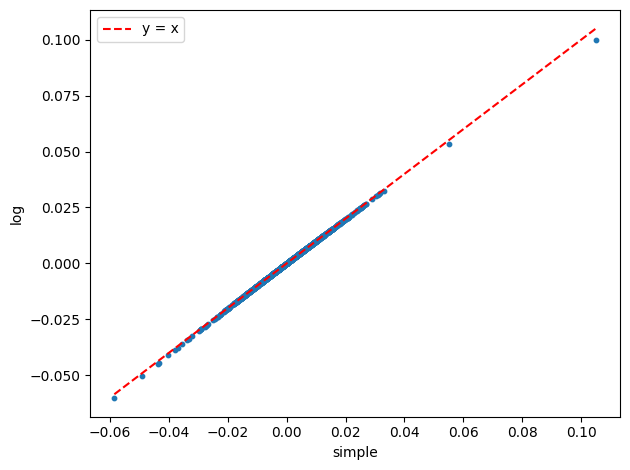

In [ ]:
returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

# fig, axes = plt.subplots(3, 1, figsize=(10, 6))


# prices.plot(ax=axes[0], title=f"{ticker} adjusted close")
# axes[0].set_ylabel("Price ($)")
# axes[0].grid(alpha=0.3)

# returns.hist(ax=axes[1], bins=80)
# axes[1].set_title(f"{ticker} daily simple returns — distribution")
# axes[1].set_xlabel("Daily return")

# log_returns.hist(ax=axes[2], bins=80)
# axes[2].set_title(f"{ticker} daily log returns — distribution")
# axes[2].set_xlabel("Daily log return")

plt.scatter(simple_returns, log_returns, s=10, alpha=1)
x = np.linspace(simple_returns.min(), simple_returns.max(), 100)
plt.plot(x, x, "r--", label="y = x")
plt.xlabel("simple"); plt.ylabel("log"); plt.legend()

plt.tight_layout()
plt.show()

This shows that the simple returns and log returns are similar around the origin but differ at the tails

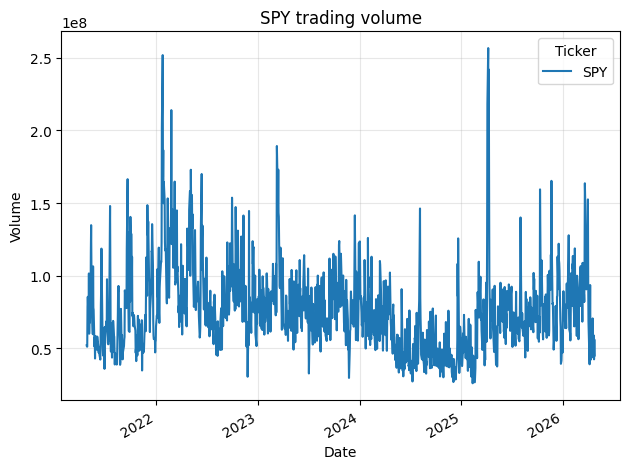

In [97]:
data["Volume"].plot(title=f"{ticker} trading volume", ylabel="Volume")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This shows that volume is not steady, that it reacts strongly during specific times, likely high stress events, but there also appear to be general trends up and down between different windows.  Such as between the beginning of the windows to around march-april 2022 general volume trended up, after the spikes volume trended down until 2025, where volume reversed and started trending up despite the stress event early 2025.